In [1]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Program Files\Python310\python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
path = kagglehub.dataset_download("pkdarabi/diagnosis-of-diabetic-retinopathy")

print("Data loaded successfuly from KaggleHub. Path to dataset files:", path)

c:\Users\PC CABA DZ\MyCode\enhanced_dr_detection\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded successfuly from KaggleHub. Path to dataset files: C:\Users\PC CABA DZ\.cache\kagglehub\datasets\pkdarabi\diagnosis-of-diabetic-retinopathy\versions\2


In [3]:
import os
os.listdir(path)

['Diagnosis of Diabetic Retinopathy', 'retino']

In [4]:
import os
base_dir = path
subdirs = [os.path.join(base_dir, d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
for subdir in subdirs:
    print(subdir)

C:\Users\PC CABA DZ\.cache\kagglehub\datasets\pkdarabi\diagnosis-of-diabetic-retinopathy\versions\2\Diagnosis of Diabetic Retinopathy
C:\Users\PC CABA DZ\.cache\kagglehub\datasets\pkdarabi\diagnosis-of-diabetic-retinopathy\versions\2\retino


In [5]:
ret_dir = os.path.join(path ,'retino')
print(ret_dir if os.path.isdir(ret_dir) else "Directory does not exist")

C:\Users\PC CABA DZ\.cache\kagglehub\datasets\pkdarabi\diagnosis-of-diabetic-retinopathy\versions\2\retino


# Prepare the data

In [6]:
!matplotlib inline

'matplotlib' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict
from pathlib import Path
def get_dataset_stats(base_dir: Path )-> Dict[str, int]:
    """
    Returns a dictionary containing image counts per class for train, valid, and test sets.
    """
    stats: Dict[str, int]= {}
    for subset in ["train", "valid", "test"]:
        subset_path = os.path.join(base_dir, subset)
        if os.path.isdir(subset_path):
            stats[subset] = {}
            for class_name in os.listdir(subset_path):
                class_path = os.path.join(subset_path, class_name)
                if os.path.isdir(class_path):
                    num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
                    stats[subset][class_name] = num_images
    return stats


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(stats: Dict[str, int])-> None:
    """
    Plots a grouped bar chart of class distributions for train, valid, and test sets with custom colors.
    """
    subsets = list(stats.keys())
    class_names = list(next(iter(stats.values())).keys())
    counts = {cls: [stats[subset].get(cls, 0) for subset in subsets] for cls in class_names}
    bar_width = 0.3
    x = np.arange(len(subsets))
    colors = ["navy", "magenta"]
    plt.figure(figsize=(10, 6))
    for i, (cls, values) in enumerate(counts.items()):
        plt.bar(x + i * bar_width, values, width=bar_width, label=cls, color=colors[i % len(colors)])
    plt.xlabel("Dataset Subset")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution Across Dataset Subsets")
    plt.xticks(x + bar_width / 2, subsets)
    plt.legend(title="Class")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


In [9]:
dataset_stats = get_dataset_stats(ret_dir)
print(dataset_stats)


{'train': {'DR': 1050, 'No_DR': 1026}, 'valid': {'DR': 245, 'No_DR': 286}, 'test': {'DR': 113, 'No_DR': 118}}


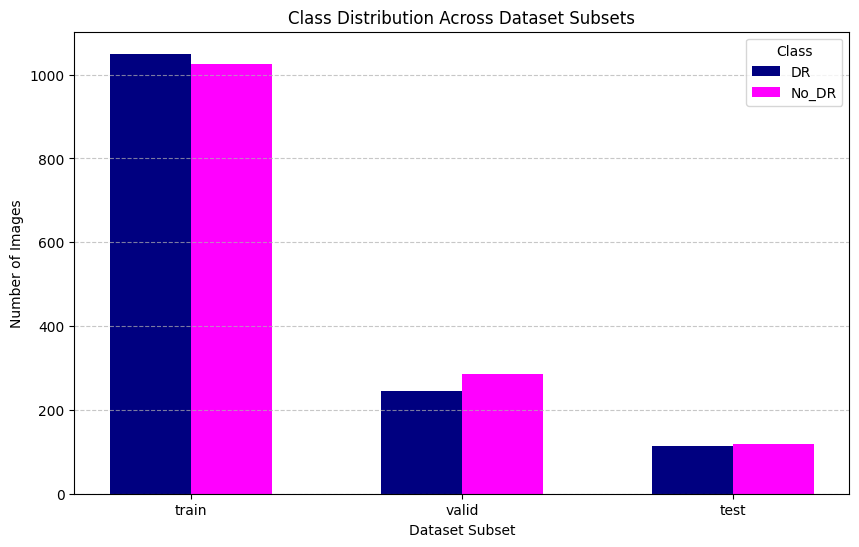

In [10]:
plot_class_distribution(dataset_stats)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

## Summary of MobileNet Architecture

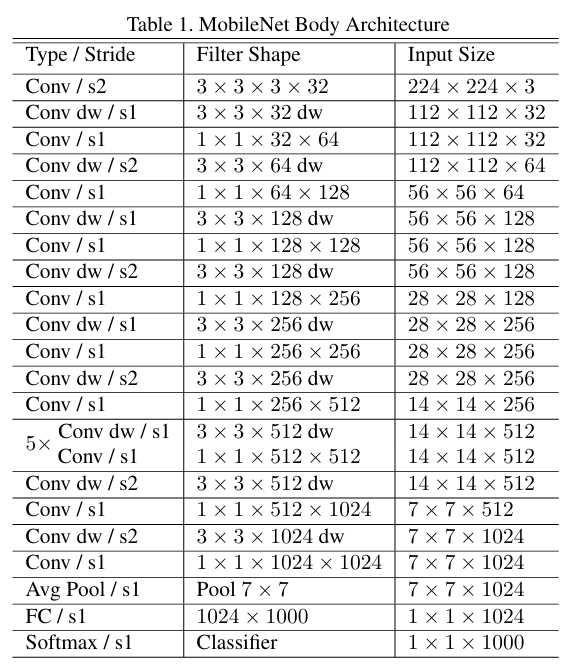

In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNet's inp size is 224*224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [13]:
train_dir = os.path.join(ret_dir, 'train')
valid_dir = os.path.join(ret_dir, 'valid')
test_dir = os.path.join(ret_dir, 'test')

train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
valid_dataset = torchvision.datasets.ImageFolder(root=valid_dir, transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [14]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


Train dataset size: 2076
Validation dataset size: 531
Test dataset size: 231


In [15]:
num_train_batches = len(train_loader)
num_valid_batches = len(valid_loader)
num_test_batches = len(test_loader)

print(f"Number of batches in training set: {num_train_batches}")
print(f"Number of batches in validation set: {num_valid_batches}")
print(f"Number of batches in test set: {num_test_batches}")


Number of batches in training set: 65
Number of batches in validation set: 17
Number of batches in test set: 8


In [16]:
print(f"Classes: {train_dataset.classes}")
print(f"Class-to-Index Mapping: {train_dataset.class_to_idx}")

Classes: ['DR', 'No_DR']
Class-to-Index Mapping: {'DR': 0, 'No_DR': 1}


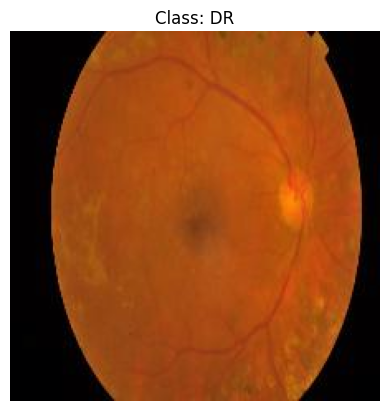

In [17]:
# here we check the loaders have been created successfully
image, label = train_dataset[1]
image = image.permute(1, 2, 0).numpy()  # change shape from (C, H, W) -> (H, W, C)
# Unnormalize
image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image = np.clip(image, 0, 1)
plt.imshow(image)
plt.title(f"Class: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()


In [18]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"Batch size: {images.shape}")
print(f"Labels: {labels}")


Batch size: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 0, 1, 0])


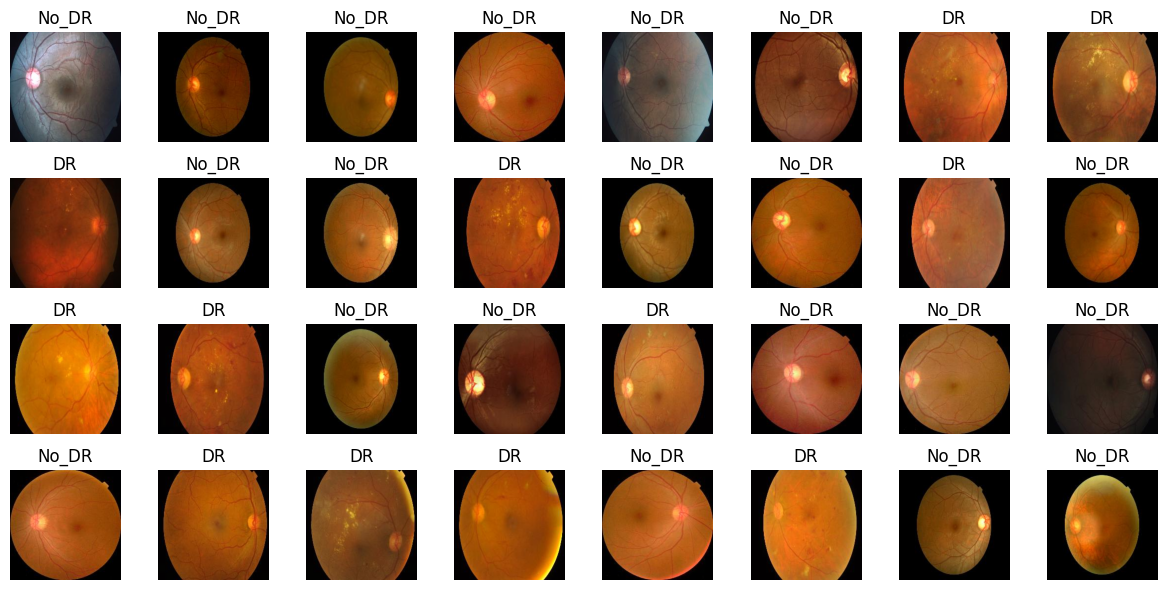

In [19]:
def show_batch(loader: DataLoader)-> None:
    """
    Check and visualise the training batch samples
    """
    dataiter = iter(loader)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))  # 32 = 4r,8c
    axes = axes.flatten()
    for img, lbl, ax in zip(images, labels, axes):
        img = img.permute(1, 2, 0).numpy()  # convert to HWC format
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(train_dataset.classes[lbl.item()])
        ax.axis("off")
    plt.tight_layout()
    plt.show()
show_batch(train_loader)


# Loading the pretrained model

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
mobilenet = models.mobilenet_v2(pretrained=True)
mobilenet = mobilenet.to(device)


Using device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\PC CABA DZ/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


c:\Users\PC CABA DZ\MyCode\enhanced_dr_detection\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC CABA DZ\MyCode\enhanced_dr_detection\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:06<00:00, 2.34MB/s]


In [30]:
mobilenet.classifier[1] = nn.Linear(in_features=1280, out_features=2)
mobilenet = mobilenet.to(device)


In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.parameters(), lr=0.0001)


In [33]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import csv
import time  # <--- Added for timing functionality

# Move model to device before starting
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mobilenet.to(device)

# training/val loop
train_losses = []
train_accuracies = []
valid_accuracies = []
num_epochs = 8

# Start total timer
total_start_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()  # <--- Start epoch timer
    
    # --- TRAINING STEP ---
    mobilenet.train()
    running_loss = 0.0
    correct, total = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # --- VALIDATION STEP ---
    mobilenet.eval()
    correct, total = 0, 0
    val_labels = []
    val_preds = []
    val_paths = []

    samples = valid_loader.dataset.samples
    sample_idx = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            batch_size = labels.size(0)
            batch_paths = [samples[i][0] for i in range(sample_idx, sample_idx + batch_size)]
            sample_idx += batch_size

            val_labels.extend(labels.cpu().tolist())
            val_preds.extend(predicted.cpu().tolist())
            val_paths.extend(batch_paths)

    valid_acc = 100 * correct / total
    valid_accuracies.append(valid_acc)

    # --- EPOCH TIMING CALCULATION ---
    epoch_duration = time.time() - epoch_start_time
    
    # --- LOGGING & REPORTS ---
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_duration:.2f}s | Train Loss: {train_losses[-1]:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Valid Acc: {valid_acc:.2f}%")
    
    class_names = valid_loader.dataset.classes
    print("\nValidation Classification Report:")
    print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

    # Identify and log misclassified images
    misclassified = []
    for path, y_true, y_pred in zip(val_paths, val_labels, val_preds):
        if y_true != y_pred:
            misclassified.append({
                'path': path,
                'true_label': class_names[y_true],
                'pred_label': class_names[y_pred]
            })

    print(f"Misclassified images this epoch: {len(misclassified)}")

    # Save misclassified list to CSV
    out_csv = f"misclassified_valid_epoch_{epoch+1}.csv"
    with open(out_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['path', 'true_label', 'pred_label'])
        writer.writeheader()
        writer.writerows(misclassified)

    # --- SAVE CHECKPOINT ---
    if epoch + 1 == num_epochs:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': mobilenet.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_losses[-1],
            'train_acc': train_accuracies[-1],
            'valid_acc': valid_acc,
        }
        torch.save(checkpoint, 'mobilenet_final_epoch.pth')
        print(f"Saved final checkpoint to: mobilenet_final_epoch.pth")

    print("-" * 70)

# --- FINAL TOTAL TIME LOGGING ---
total_duration = time.time() - total_start_time
minutes = int(total_duration // 60)
seconds = int(total_duration % 60)
print(f"TRAINING COMPLETE. Total time: {minutes}m {seconds}s")

Epoch [1/8] | Time: 151.20s | Train Loss: 0.0645 | Train Acc: 97.74% | Valid Acc: 97.36%

Validation Classification Report:
              precision    recall  f1-score   support

          DR     0.9915    0.9510    0.9708       245
       No_DR     0.9595    0.9930    0.9759       286

    accuracy                         0.9736       531
   macro avg     0.9755    0.9720    0.9734       531
weighted avg     0.9742    0.9736    0.9736       531

Misclassified images this epoch: 14
----------------------------------------------------------------------
Epoch [2/8] | Time: 122.88s | Train Loss: 0.0155 | Train Acc: 99.47% | Valid Acc: 96.61%

Validation Classification Report:
              precision    recall  f1-score   support

          DR     0.9913    0.9347    0.9622       245
       No_DR     0.9467    0.9930    0.9693       286

    accuracy                         0.9661       531
   macro avg     0.9690    0.9639    0.9657       531
weighted avg     0.9673    0.9661    0.9660   

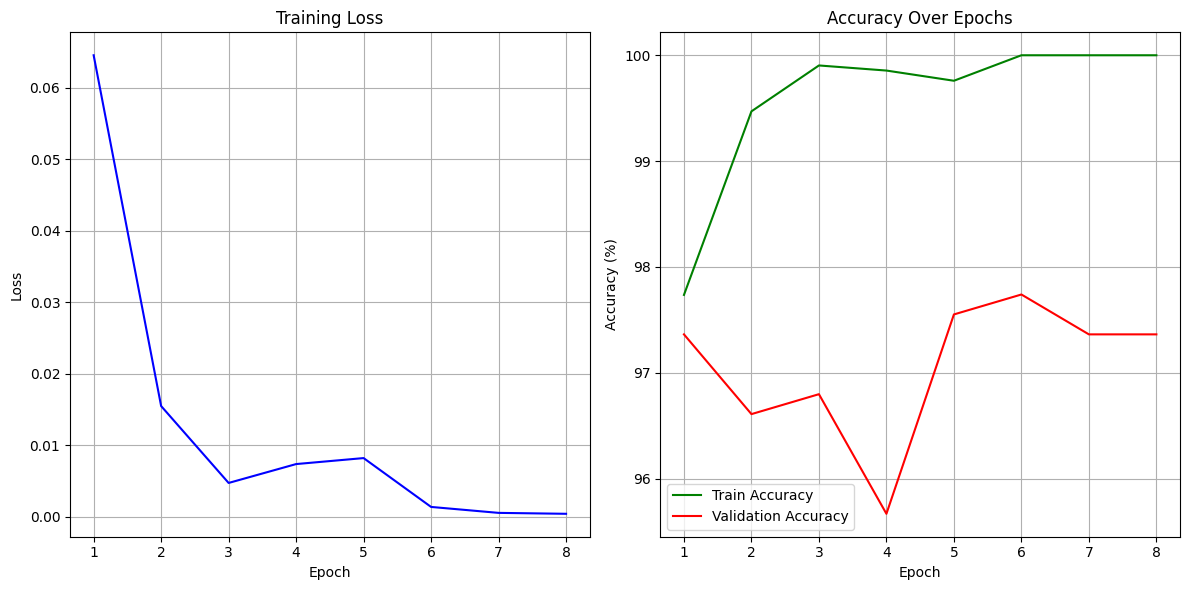

In [34]:
# Plotting the loss and accuracy curves
plt.figure(figsize=(12, 6))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy", color='green')
plt.plot(range(1, num_epochs + 1), valid_accuracies, label="Validation Accuracy", color='red')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Over Epochs")
plt.legend()
plt.grid(True)

# Show the plots
plt.tight_layout()
plt.show()


Test Accuracy: 97.84%
Classification Report:
              precision    recall  f1-score   support

          DR     0.9821    0.9735    0.9778       113
       No_DR     0.9748    0.9831    0.9789       118

    accuracy                         0.9784       231
   macro avg     0.9785    0.9783    0.9783       231
weighted avg     0.9784    0.9784    0.9784       231



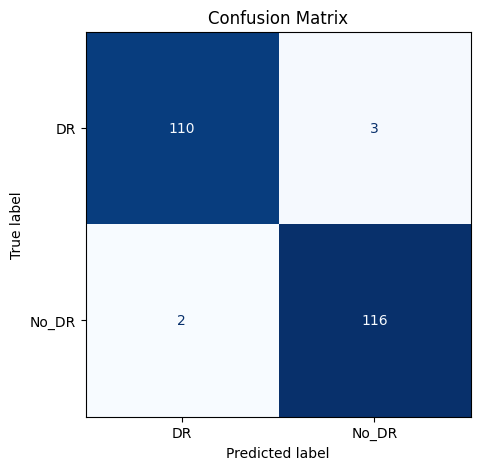

Misclassified images: 5
Saved misclassified list to: misclassified_images_v2.csv


In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

mobilenet.eval()
correct, total = 0, 0
all_labels = []
all_preds = []
all_probs = []
all_paths = []

# ImageFolder keeps samples in order; test_loader is shuffle=False, so we can map by index
samples = test_loader.dataset.samples
sample_idx = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        batch_size = labels.size(0)
        batch_paths = [samples[i][0] for i in range(sample_idx, sample_idx + batch_size)]
        sample_idx += batch_size

        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(predicted.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_paths.extend(batch_paths)

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

# Detailed classification report
class_names = test_loader.dataset.classes
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Confusion matrix plot
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False
)
plt.title('Confusion Matrix')
plt.show()

# Log misclassified images
misclassified = []
for path, y_true, y_pred, prob in zip(all_paths, all_labels, all_preds, all_probs):
    if y_true != y_pred:
        misclassified.append({
            'path': path,
            'true_label': class_names[y_true],
            'pred_label': class_names[y_pred],
            'pred_confidence': float(max(prob))
        })

print(f"Misclassified images: {len(misclassified)}")

# Save to CSV for inspection
import csv
out_csv = 'misclassified_images_v2.csv'
with open(out_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['path', 'true_label', 'pred_label', 'pred_confidence'])
    writer.writeheader()
    writer.writerows(misclassified)

print(f"Saved misclassified list to: {out_csv}")


In [27]:
# disable CUDA
torch.cuda.is_available = lambda: False  
mobilenet.eval() 
mobilenet.to("cpu")  

# check that all parameters are on CPU
for param in mobilenet.parameters():
    assert param.device.type == "cpu", "Error: Model contains parameters on GPU!"

example_input = torch.randn(1, 3, 224, 224)  # No `.to("cuda")` calls
with torch.no_grad():
    output = mobilenet(example_input)
print("CPU-only inference successful!")
traced_model = torch.jit.trace(mobilenet, example_input)
traced_model.save("mobilenet_cpu_only.pt")


CPU-only inference successful!


`torch.jit.trace` is used to convert your PyTorch model into TorchScript, a way to optimize and serialize the model for deployment. TorchScript allows the model to be run independently of Python, making it suitable for mobile and production environments.
  - Tracing: This method traces the model's operations by running it on the provided example input (the dummy tensor). It records the operations performed during this forward pass and generates a representation of those operations that can be saved and executed without the Python runtime.


```
val module = LiteModuleLoader.load(assetFilePath(context, "mobilenet_diabetic_retinopathy.pt"))
val inputTensor = TensorImageUtils.bitmapToFloat32Tensor(bitmap, mean, std)
val outputTensor = module.forward(IValue.from(inputTensor)).toTensor()
val scores = outputTensor.dataAsFloatArray

```

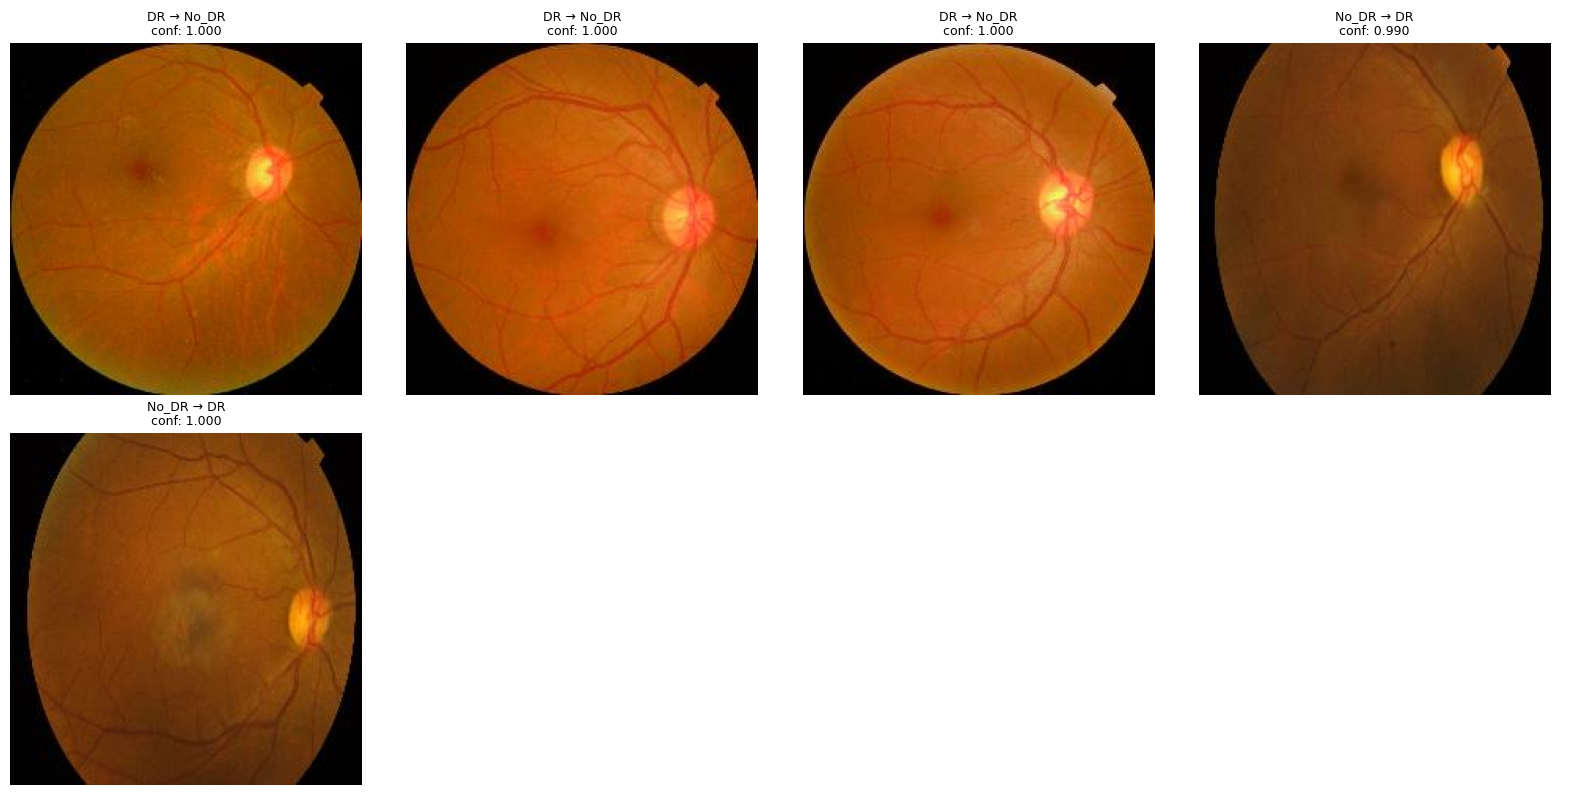

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import math

# path to your CSV
csv_path = "misclassified_images_v2.csv"  # or misclassified_valid_epoch_1.csv, etc.

df = pd.read_csv(csv_path)

def show_misclassified(df, n=16, cols=4):
    df = df.head(n)
    rows = math.ceil(len(df) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, df.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        title = f'{row["true_label"]} → {row["pred_label"]}\nconf: {row["pred_confidence"]:.3f}'
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    # hide any extra axes
    for ax in axes[len(df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified(df, n=12, cols=4)
